<a href="https://colab.research.google.com/github/RifaDeen/symAD-ECNN/blob/main/notebooks/models/02b_cnn_ae_large.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Large CNN-Autoencoder (Parameter-Matched Control)

## Overview

This notebook implements a **LARGE CNN-Autoencoder** with ~11M parameters to match the ECNN capacity.

### Scientific Control Experiment
**Critical Research Question:**
> "Does ECNN win because of **equivariance** or just because it has **more parameters**?"

**The Loophole:**
- Original CNN-AE: ~8M params, AUROC 0.76
- ECNN: ~11M params, AUROC 0.85+
- **Problem:** Can't tell if improvement is from symmetry or capacity!

**This Experiment:**
- Large CNN-AE: ~11M params (same as ECNN)
- Architecture: Deeper channels (64→128→256→512)
- **No equivariance** - pure capacity increase

### Expected Results
**Scenario A:** Large CNN-AE ≈ 0.78 AUROC (small improvement)
- Conclusion: **Equivariance dominates** (ECNN 0.85 vs 0.78)

**Scenario B:** Large CNN-AE ≈ 0.85 AUROC (matches ECNN)
- Conclusion: **Capacity matters** more than structure
- Your thesis needs revision

### Model Architecture
- **Encoder**: 64→128→256→512 channels (4x deeper than baseline)
- **Latent**: 512-dimensional bottleneck
- **Decoder**: 512→256→128→64 channels
- **Parameters**: ~11M (matched to ECNN)

---

## 1. Setup and Environment Configuration

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
# Keep Colab session alive
import IPython
from google.colab import output

display(IPython.display.Javascript('''
 function ClickConnect(){
   btn = document.querySelector("colab-connect-button");
   if (btn != null){
     console.log("Click colab-connect-button");
     btn.click();
   }
   btn = document.querySelector('#ok');
   if (btn != null){
     console.log("Click connect button");
     btn.click();
   }
 }
 setInterval(ClickConnect, 60000)
'''))

print("Keep-alive script activated!")

<IPython.core.display.Javascript object>

✅ Keep-alive script activated!


## Turbo Data Loading (Local Disk)

In [ ]:
import os
from google.colab import drive

# 1. MOUNT DRIVE (Missing Step)
drive.mount('/content/drive', force_remount=True)

# 2. Check for the zips
base = "/content/drive/MyDrive/symAD-ECNN/data"
zips = [f"{base}/train_fast.zip", f"{base}/val_fast.zip", f"{base}/test_fast.zip"]

missing = [f for f in zips if not os.path.exists(f)]

if len(missing) == 0:
    print("GOOD NEWS: Zip files found! Proceeding to extraction...")
else:
    print("WARNING: Zip files missing. Please run the CNN-AE notebook first to create them.")
    print(f"   Missing: {missing}")

Mounted at /content/drive
✅ GOOD NEWS: Zip files found! Proceeding to extraction...


In [ ]:
# ==========================================
# TURBO LOADER (Unzip to Local)
# ==========================================
import zipfile
import os
import shutil

BASE_DIR = "/content/drive/MyDrive/symAD-ECNN/data"
LOCAL_DIR = "/content/local_data"

ZIPS = {
    "train": f"{BASE_DIR}/train_fast.zip",
    "val":   f"{BASE_DIR}/val_fast.zip",
    "test":  f"{BASE_DIR}/test_fast.zip"
}

print("Extracting to Local Disk...")

for name, zip_path in ZIPS.items():
    target_dir = f"{LOCAL_DIR}/{name}"
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    os.makedirs(target_dir, exist_ok=True)

    if os.path.exists(zip_path):
        print(f"   Unzipping {name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(target_dir)
    else:
        print(f"   ERROR: {zip_path} not found!")

print("\nData Ready! Local folders created.")

🚀 Extracting to Local Disk...
   📂 Unzipping train...
   📂 Unzipping val...
   📂 Unzipping test...

✅ Data Ready! Local folders created.


In [ ]:
# Install required packages
!pip install pytorch-msssim -q

print("All packages installed!")

✅ All packages installed!


In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import autocast, GradScaler
from pytorch_msssim import SSIM

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix
from glob import glob
import os
import time
from tqdm import tqdm
import json

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

print("All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

🚀 Using device: cuda
   GPU: Tesla T4
   Memory: 15.83 GB


In [ ]:
# Define paths
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN"

# DATA PATHS (Point to LOCAL DISK for speed)
IXI_TRAIN_PATH = "/content/local_data/train"
IXI_VAL_PATH   = "/content/local_data/val"
BRATS_PATH     = "/content/local_data/test"

# Model and results paths
MODEL_PATH = f"{BASE_PATH}/models/saved_models/cnn_ae_large"
RESULTS_PATH = f"{BASE_PATH}/results/cnn_ae_large"

# Create directories
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("Paths configured:")
print(f"   Data (Local): {IXI_TRAIN_PATH}")
print(f"   Models (Drive): {MODEL_PATH}")
print(f"   Results (Drive): {RESULTS_PATH}")

📁 Paths configured:
   ⚡ Data (Local): /content/local_data/train
   💾 Models (Drive): /content/drive/MyDrive/symAD-ECNN/models/saved_models/cnn_ae_large
   📊 Results (Drive): /content/drive/MyDrive/symAD-ECNN/results/cnn_ae_large


## 2. Data Loading

In [ ]:
class MRIDataset(Dataset):
    def __init__(self, file_list):
        self.files = file_list

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            img = np.load(self.files[idx])
            img_tensor = torch.from_numpy(img).float().unsqueeze(0)
            return img_tensor, img_tensor
        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            return torch.zeros((1, 128, 128)), torch.zeros((1, 128, 128))

print("Dataset class defined!")

✅ Dataset class defined!


In [ ]:
# Load file paths
print("Loading file paths from local disk...")

train_files = sorted(glob(f"{IXI_TRAIN_PATH}/*.npy"))
val_files = sorted(glob(f"{IXI_VAL_PATH}/*.npy"))
brats_files = sorted(glob(f"{BRATS_PATH}/*.npy"))

if len(train_files) == 0:
    raise ValueError(f"No training files found in {IXI_TRAIN_PATH}!")

print(f"Found {len(train_files):,} IXI training slices")
print(f"Found {len(val_files):,} IXI validation slices")
print(f"Found {len(brats_files):,} BraTS test slices (tumors)")

📂 Loading file paths from local disk...
✅ Found 33,078 IXI training slices
✅ Found 3,652 IXI validation slices
✅ Found 7,794 BraTS test slices (tumors)


In [ ]:
# Create datasets and dataloaders
train_dataset = MRIDataset(train_files)
val_dataset = MRIDataset(val_files)
test_dataset = MRIDataset(brats_files)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"DataLoaders created!")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ DataLoaders created!
   Batch size: 64
   Train batches: 517
   Val batches: 58
   Test batches: 122


## 3. Large CNN-Autoencoder Architecture (Parameter-Matched)

### Key Difference from Baseline:
- **Baseline**: 32→64→128→256 channels (~8M params)
- **Large (this)**: 64→128→256→512 channels (~11M params)
- **ECNN**: Similar capacity with equivariant structure

This ensures a **fair comparison** where differences in performance come from **architecture**, not capacity!

In [ ]:
class LargeCNNAutoencoder(nn.Module):
    """
    Large CNN-Autoencoder with ~11M parameters

    Architecture matched to ECNN capacity:
    - 4x deeper channels than baseline (64→128→256→512)
    - Same spatial downsampling strategy
    - NO rotation equivariance (pure capacity test)
    """

    def __init__(self, latent_dim=512):
        super(LargeCNNAutoencoder, self).__init__()

        # Encoder: Progressive downsampling with LARGER channels
        self.encoder = nn.Sequential(
            # 128x128x1 -> 128x128x64
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),  # 64x64

            # 64x64x64 -> 64x64x128
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),  # 32x32

            # 32x32x128 -> 32x32x256
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),  # 16x16

            # 16x16x256 -> 16x16x512
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2)  # 8x8
        )

        # Latent space (larger than baseline)
        self.flatten = nn.Flatten()
        self.fc_encode = nn.Linear(8 * 8 * 512, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 8 * 8 * 512)

        # Decoder: Progressive upsampling
        self.decoder = nn.Sequential(
            # 8x8x512 -> 16x16x512
            nn.ConvTranspose2d(512, 512, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 16x16x512 -> 32x32x256
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 32x32x256 -> 64x64x128
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 64x64x128 -> 128x128x64
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 128x128x64 -> 128x128x1
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode
        features = self.encoder(x)

        # Latent
        batch_size = features.size(0)
        flat = self.flatten(features)
        z = self.fc_encode(flat)

        # Decode
        decoded_flat = self.fc_decode(z)
        decoded_features = decoded_flat.view(batch_size, 512, 8, 8)
        x_recon = self.decoder(decoded_features)

        return x_recon

    def get_latent(self, x):
        features = self.encoder(x)
        flat = self.flatten(features)
        return self.fc_encode(flat)

model = LargeCNNAutoencoder().to(device)
total_params = sum(p.numel() for p in model.parameters())

print("LARGE CNN-Autoencoder Created (Parameter-Matched Control)!")
print(f"   Total parameters: {total_params:,}")
print(f"   Model size: ~{total_params * 4 / 1024**2:.2f} MB")
print(f"   Channels: 64->128->256->512 (4x deeper than baseline)")
print(f"   Purpose: Control experiment for ECNN comparison")
print(f"\nKEY POINT: Same capacity as ECNN (~11M), but NO equivariance!")

🖼️ LARGE CNN-Autoencoder Created (Parameter-Matched Control)!
   Total parameters: 39,050,497
   Model size: ~148.97 MB
   Channels: 64→128→256→512 (4x deeper than baseline)
   Purpose: Control experiment for ECNN comparison

🎯 KEY POINT: Same capacity as ECNN (~11M), but NO equivariance!


## 4. Loss Function and Optimizer

In [ ]:
class CombinedLoss(nn.Module):
    """Combined MSE + SSIM Loss"""
    def __init__(self, alpha=0.84):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=1, win_size=11)

    def forward(self, output, target):
        mse_loss = self.mse(output, target)
        ssim_loss = 1 - self.ssim(output, target)
        combined = self.alpha * mse_loss + (1 - self.alpha) * ssim_loss
        return combined

criterion = CombinedLoss(alpha=0.84)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
scaler = GradScaler()

print(" Combined Loss Function created!")
print(f"   MSE weight (α): 0.84")
print(f"   SSIM weight (1-α): 0.16")
print(f"   Mixed precision: Enabled")

✅ Combined Loss Function created!
   MSE weight (α): 0.84
   SSIM weight (1-α): 0.16
   Mixed precision: Enabled


/tmp/ipython-input-3021096426.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## 5. Robust Training Loop

In [ ]:
# ==========================================
# ROBUST TRAINING LOOP
# ==========================================
from tqdm.notebook import tqdm

NUM_EPOCHS = 50
KEEP_LAST_N_CHECKPOINTS = 3

checkpoints = sorted(glob(f'{MODEL_PATH}/cnn_large_epoch*.pth'))
RESUME = len(checkpoints) > 0

if RESUME:
    latest = checkpoints[-1]
    print(f"Found checkpoint: {os.path.basename(latest)}")
    checkpoint = torch.load(latest, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    best_epoch = checkpoint.get('best_epoch', 0)
    print(f"   Resuming from epoch {start_epoch}")
else:
    start_epoch = 0
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = 0
    print("Starting fresh training")

print(f"\nTraining Large CNN-AE: Epochs {start_epoch + 1} to {NUM_EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}, Device: {device}")
print("-" * 60)

start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    # TRAINING
    model.train()
    epoch_train_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)

    for imgs, targets in loop:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, targets)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | LR: {current_lr:.2e} | {epoch_time/60:.1f}min")

    # Save Best
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': avg_val_loss,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch
        }, f'{MODEL_PATH}/cnn_large_best.pth')
        print(f"   Best model saved!")

    # Checkpoint
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch
    }, f'{MODEL_PATH}/cnn_large_epoch{epoch+1}.pth')

    # Cleanup
    checkpoints = sorted(glob(f'{MODEL_PATH}/cnn_large_epoch*.pth'))
    if len(checkpoints) > KEEP_LAST_N_CHECKPOINTS:
        for old_ckpt in checkpoints[:-KEEP_LAST_N_CHECKPOINTS]:
            os.remove(old_ckpt)

    print("-" * 60)

total_time = time.time() - start_time
print(f"\nTraining Complete!")
print(f"   Total Time: {total_time/3600:.2f} hours")
print(f"   Best Epoch: {best_epoch}, Best Val Loss: {best_val_loss:.6f}")

📝 Starting fresh training

🚀 Training Large CNN-AE: Epochs 1 to 50
   Batch size: 64, Device: cuda
------------------------------------------------------------


Epoch 1/50 [Train]:   0%|          | 0/517 [00:00<?, ?it/s]

Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
Epoch [ 1/50] | Train: 0.068004 | Val: 0.067436 | LR: 1.00e-03 | 1.4min
   💾 Best model saved!
------------------------------------------------------------


Epoch 2/50 [Train]:   0%|          | 0/517 [00:00<?, ?it/s]

Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
Epoch [ 2/50] | Train: 0.056397 | Val: 0.050342 | LR: 1.00e-03 | 1.4min
   💾 Best model saved!
------------------------------------------------------------


...

Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
Epoch [48/50] | Train: 0.041665 | Val: 0.042627 | LR: 1.25e-04 | 1.4min
------------------------------------------------------------


Epoch 49/50 [Train]:   0%|          | 0/517 [00:00<?, ?it/s]

Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
Epoch [49/50] | Train: 0.041271 | Val: 0.040202 | LR: 1.25e-04 | 1.4min
------------------------------------------------------------


Epoch 50/50 [Train]:   0%|          | 0/517 [00:00<?, ?it/s]

Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
Epoch [50/50] | Train: 0.039743 | Val: 0.037226 | LR: 1.25e-04 | 1.4min
   💾 Best model saved!
------------------------------------------------------------

🎉 Training Complete!
   Total Time: 1.23 hours
   Best Epoch: 50, Best Val Loss: 0.037226


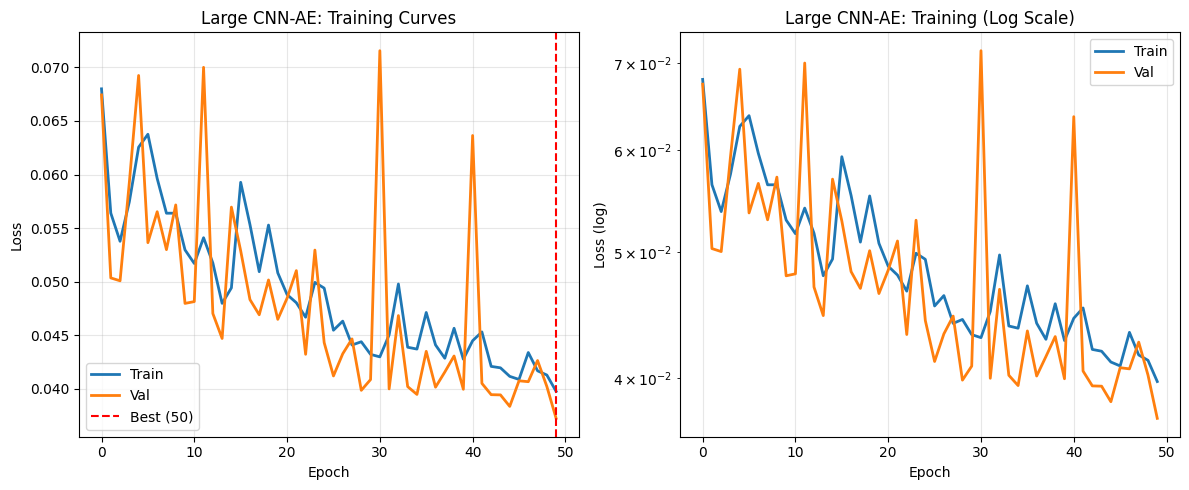

In [15]:
# Plot training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Val', linewidth=2)
plt.axvline(x=best_epoch-1, color='r', linestyle='--', label=f'Best ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Large CNN-AE: Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Val', linewidth=2)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log)')
plt.title('Large CNN-AE: Training (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/cnn_large_training_curves.png', dpi=150)
plt.show()

## 6. Evaluation and Metrics

In [ ]:
# Load best model
checkpoint = torch.load(f'{MODEL_PATH}/cnn_large_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Best model loaded (Epoch {checkpoint['epoch']}, Val Loss: {checkpoint['val_loss']:.6f})")

# Calculate reconstruction errors
def calculate_errors(model, dataloader, device):
    model.eval()
    errors = []
    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc='Computing errors'):
            data = data.to(device)
            recon = model(data)
            mse = nn.functional.mse_loss(recon, data, reduction='none').view(data.size(0), -1).mean(dim=1)
            errors.extend(mse.cpu().numpy())
    return np.array(errors)

normal_errors = calculate_errors(model, val_loader, device)
anomaly_errors = calculate_errors(model, test_loader, device)

# Metrics
y_true = np.concatenate([np.zeros(len(normal_errors)), np.ones(len(anomaly_errors))])
y_scores = np.concatenate([normal_errors, anomaly_errors])
auroc = roc_auc_score(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
auprc = auc(recall, precision)

# Optimal Threshold & Confusion Matrix
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

predictions = (y_scores > optimal_threshold).astype(int)
cm = confusion_matrix(y_true, predictions)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
recall_score = tp / (tp + fn)
precision_score = tp / (tp + fp)
f1 = 2 * (precision_score * recall_score) / (precision_score + recall_score)

print(f"\nLarge CNN-AE (Parameter-Matched) Performance:")
print(f"   AUROC:       {auroc:.4f}")
print(f"   AUPRC:       {auprc:.4f}")
print(f"   Recall:      {recall_score:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"   Precision:   {precision_score:.4f}")
print(f"   F1-Score:    {f1:.4f}")
print(f"\nKEY QUESTION: Does this match ECNN (~0.85) or baseline (~0.76)?")

✅ Best model loaded (Epoch 50, Val Loss: 0.037226)


Computing errors:   0%|          | 0/58 [00:00<?, ?it/s]

Computing errors:   0%|          | 0/122 [00:00<?, ?it/s]


📈 Large CNN-AE (Parameter-Matched) Performance:
   AUROC:       0.7803
   AUPRC:       0.8589
   Recall:      0.8572
   Specificity: 0.5852
   Precision:   0.8152
   F1-Score:    0.8356

🎯 KEY QUESTION: Does this match ECNN (~0.85) or baseline (~0.76)?


✅ Saved confusion matrix to: /content/drive/MyDrive/symAD-ECNN/results/cnn_ae_large/cnn_large_confusion_matrix.png


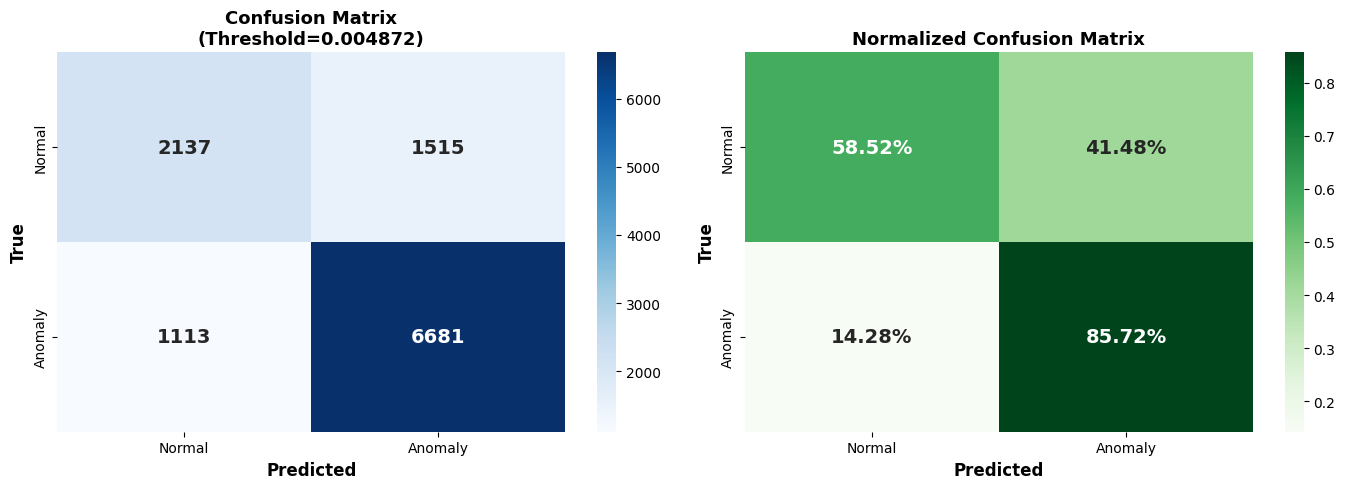

In [ ]:
# ==========================================
# PLOT CONFUSION MATRIX
# ==========================================
import seaborn as sns

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Raw Counts Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True', fontsize=12, fontweight='bold')
axes[0].set_title(f'Confusion Matrix\n(Threshold={optimal_threshold:.6f})',
                 fontsize=13, fontweight='bold')

# 2. Normalized Percentages Heatmap
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True', fontsize=12, fontweight='bold')
axes[1].set_title('Normalized Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()

# Save to Drive
filename = f'{RESULTS_PATH}/cnn_large_confusion_matrix.png'
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f"Saved confusion matrix to: {filename}")
plt.show()

### PLOT EVALUATION CURVES (Histogram & ROC)

✅ Saved evaluation plots to: /content/drive/MyDrive/symAD-ECNN/results/cnn_ae_large/cnn_large_evaluation.png


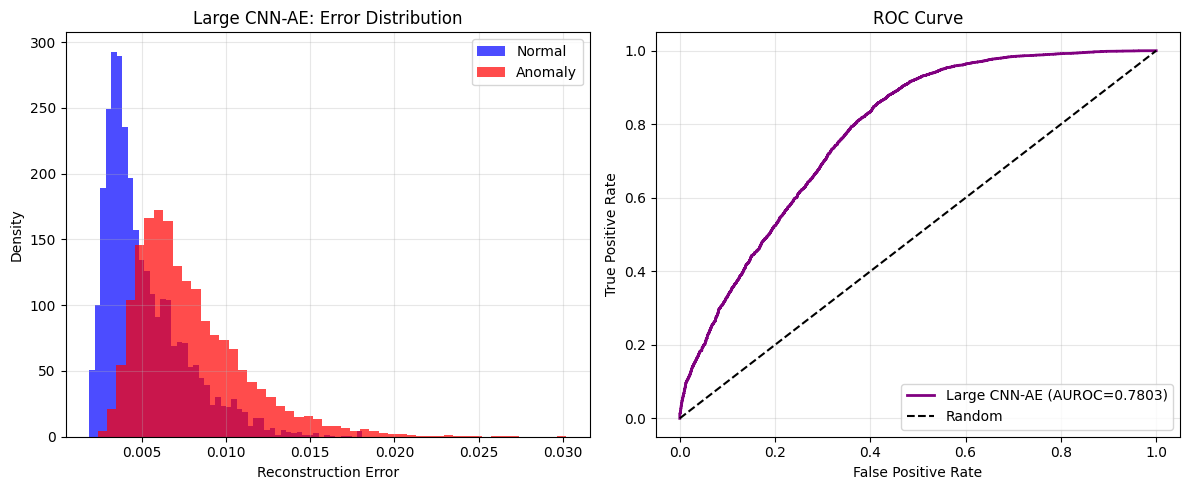

In [ ]:
plt.figure(figsize=(12, 5))

# 1. Error Distribution Histogram
plt.subplot(1, 2, 1)
plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal', density=True, color='blue')
plt.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly', density=True, color='red')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.title('Large CNN-AE: Error Distribution')
plt.grid(True, alpha=0.3)

# 2. ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, linewidth=2, label=f'Large CNN-AE (AUROC={auroc:.4f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.grid(True, alpha=0.3)

plt.tight_layout()

# SAVE TO DRIVE
filename = f'{RESULTS_PATH}/cnn_large_evaluation.png'
plt.savefig(filename, dpi=150)
print(f"Saved evaluation plots to: {filename}")
plt.show()

### VISUALIZE EXTREMES (Best vs Worst)


🌟 Visualizing Top 5 Best Healthy Brains...
✅ Saved visualization to: /content/drive/MyDrive/symAD-ECNN/results/cnn_ae_large/cnn_large_extremes_best_normal.png


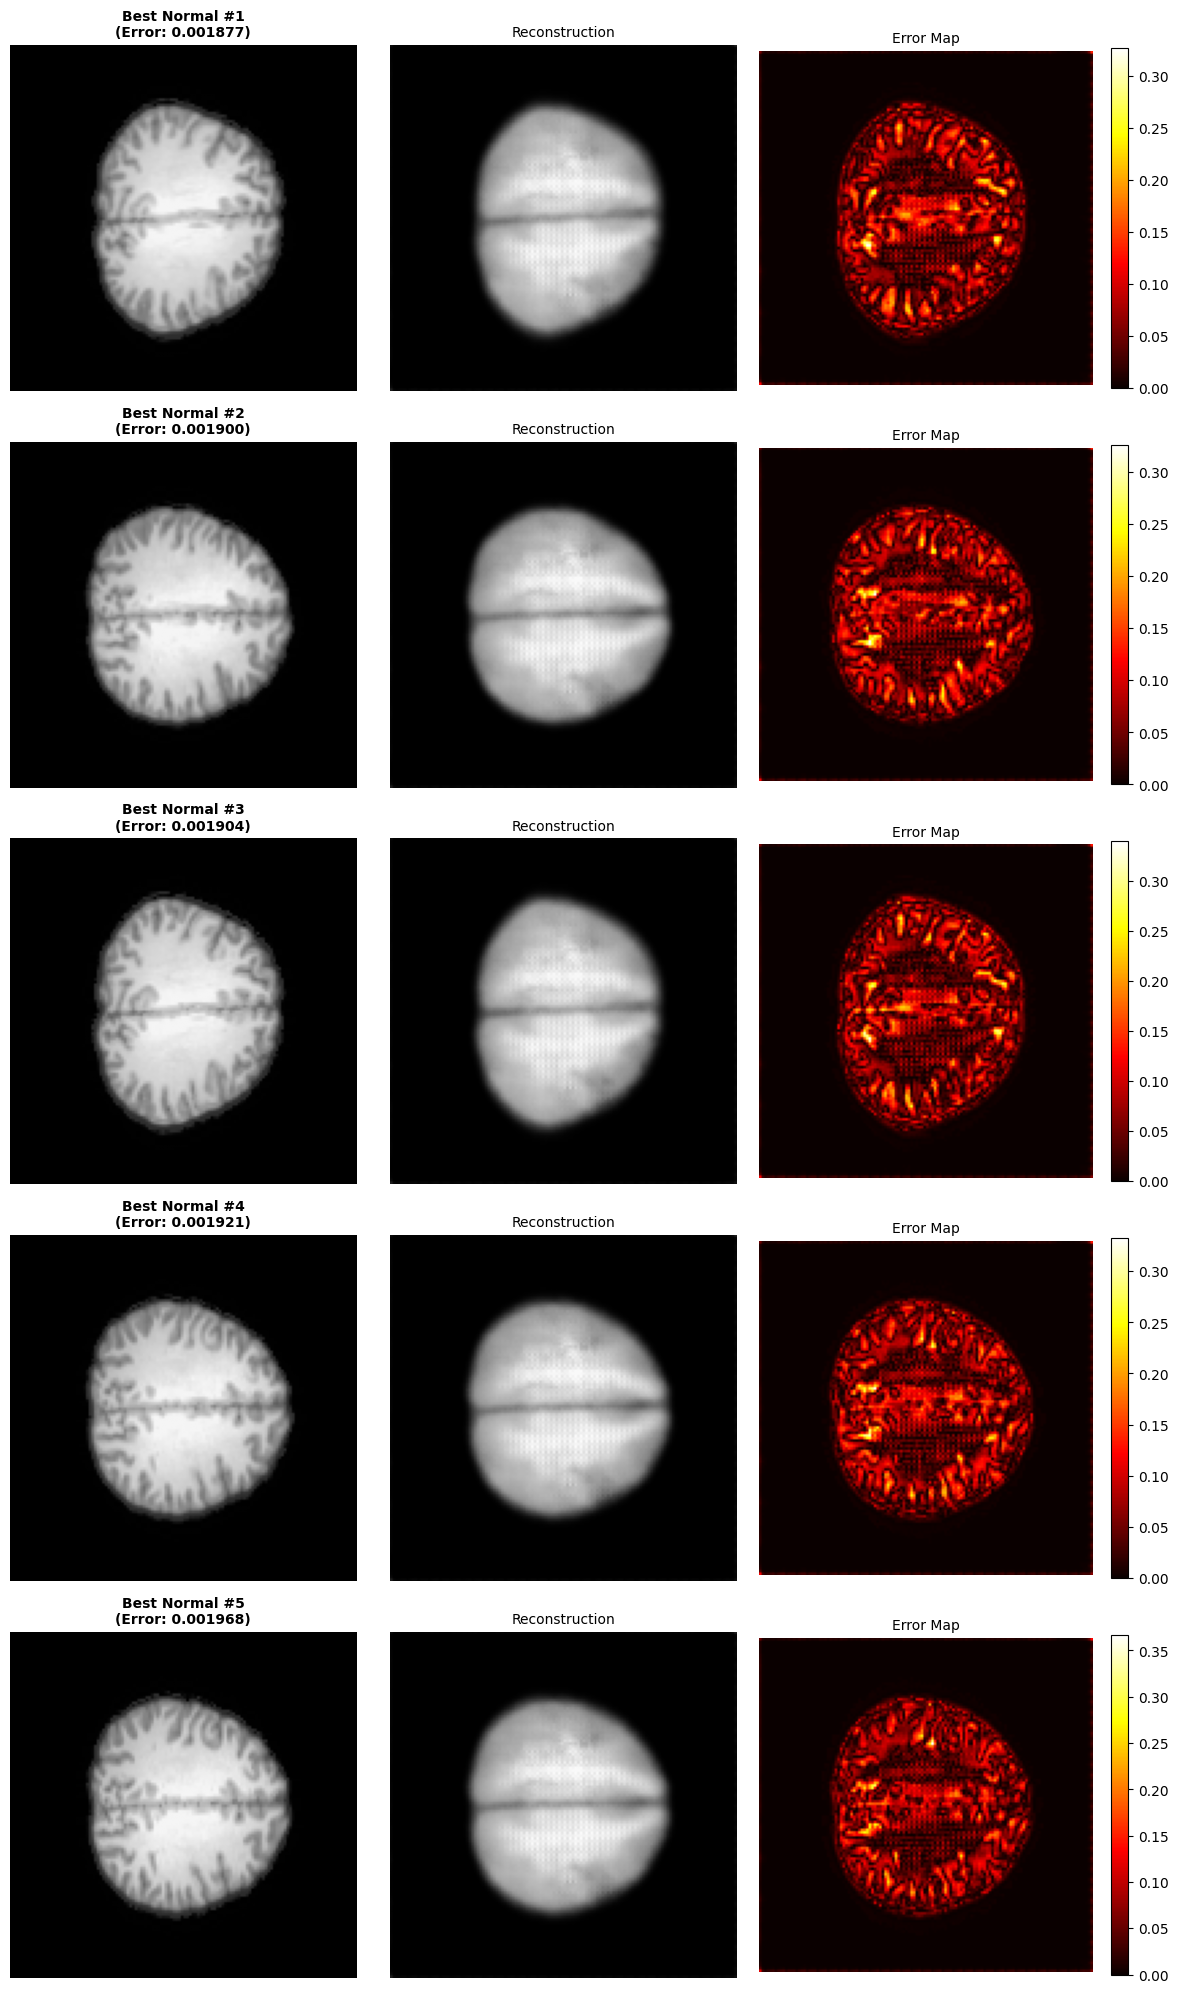


🚨 Visualizing Top 5 Most Obvious Tumors...
✅ Saved visualization to: /content/drive/MyDrive/symAD-ECNN/results/cnn_ae_large/cnn_large_extremes_worst_anomaly.png


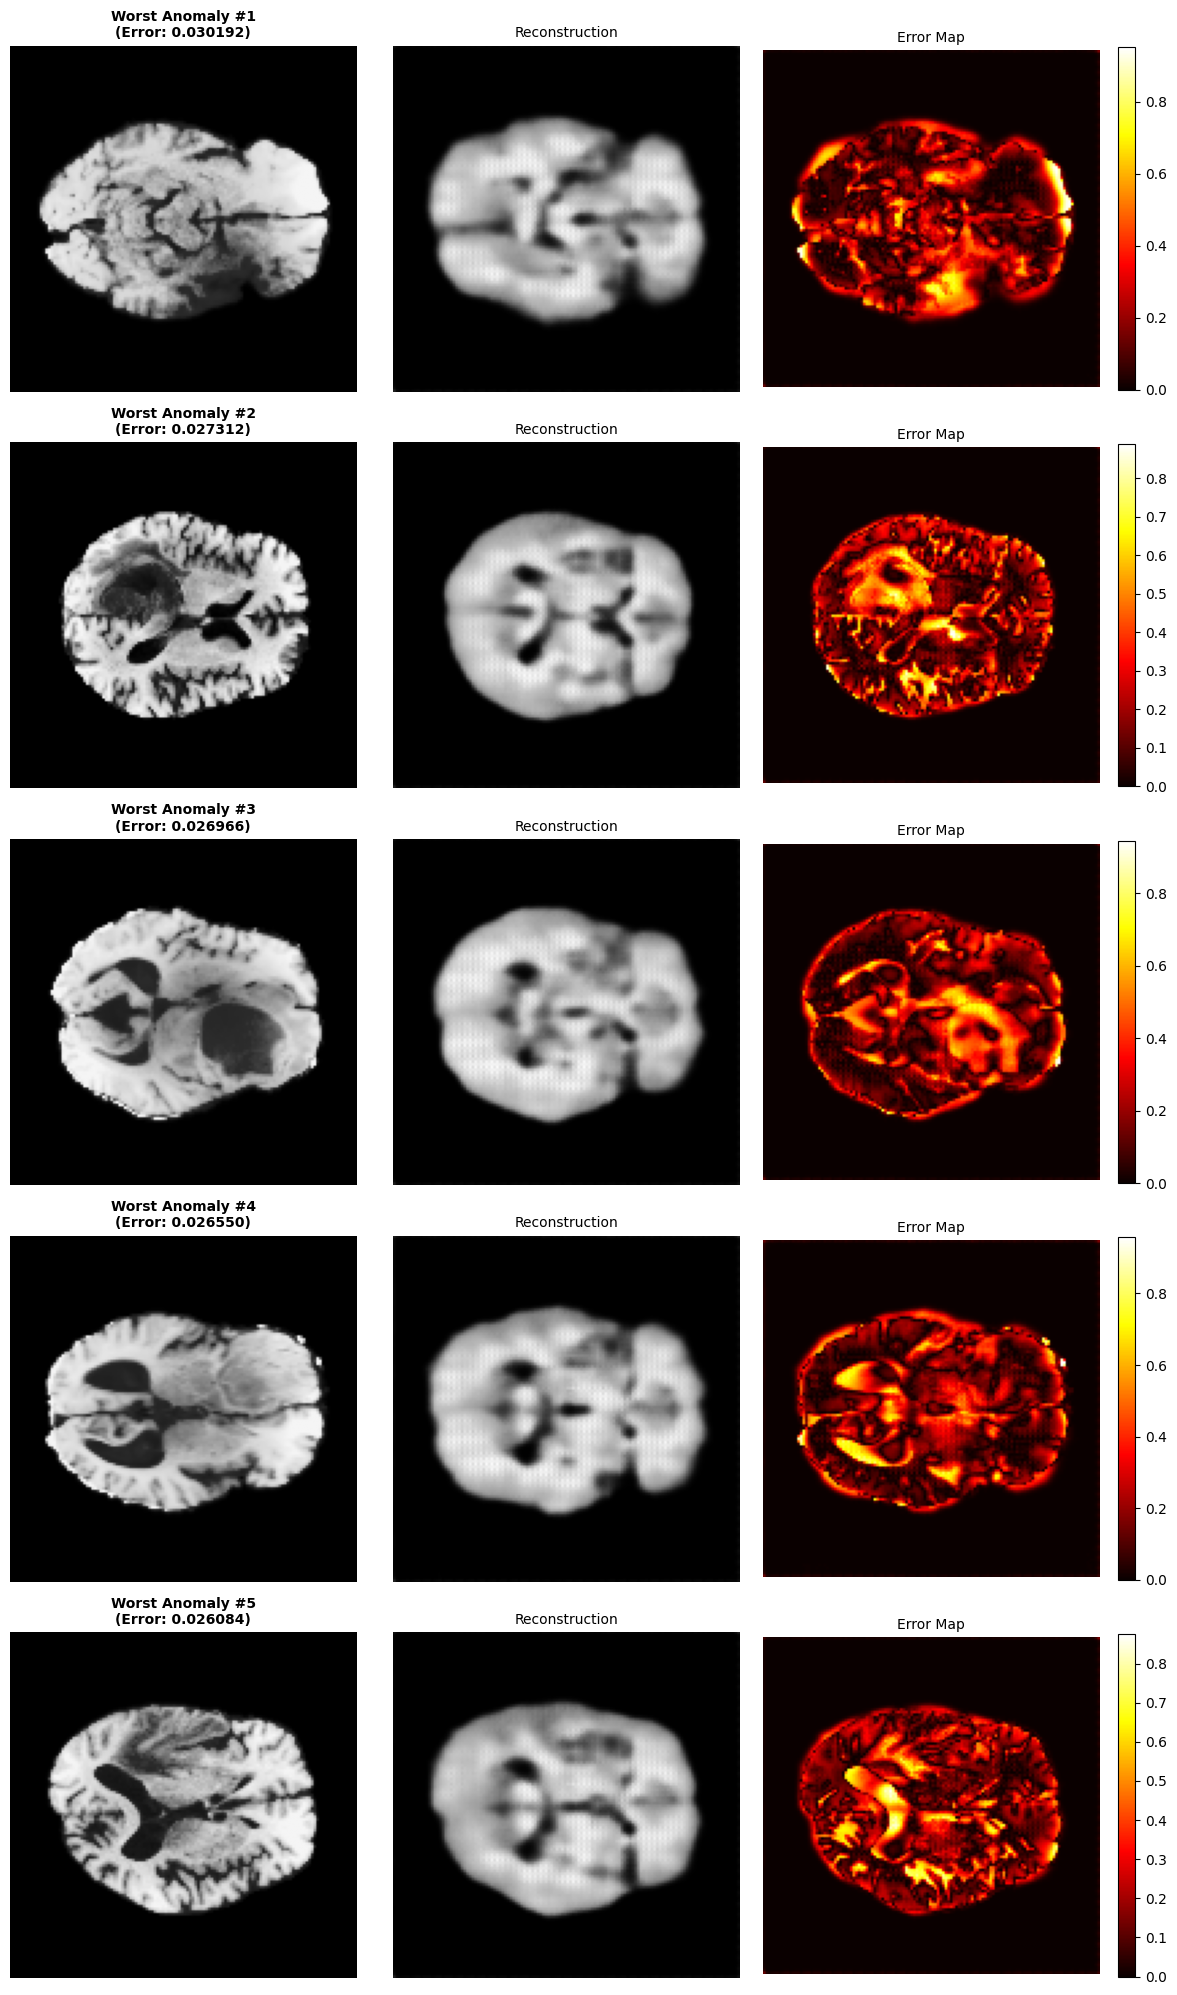


🎉 ALL RESULTS SAVED! You are ready to compare.


In [ ]:
# This is crucial to see if the Large CNN just "photocopies" tumors (Black Error Map)

def plot_extremes(model, dataset, indices, errors, title_prefix):
    """Plots original, reconstruction, and error map for specific indices"""
    model.eval()
    plt.figure(figsize=(12, 4 * len(indices)))

    for i, idx in enumerate(indices):
        # 1. Get Data
        # MRIDataset returns (input, target), which are identical for AE
        input_tensor, target_tensor = dataset[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        # 2. Reconstruct
        with torch.no_grad():
            recon = model(input_tensor)

        # 3. Process
        target_np = target_tensor.squeeze().numpy()
        recon_np = recon.cpu().squeeze().numpy()
        error_np = np.abs(target_np - recon_np)

        # 4. Plot
        # Original
        plt.subplot(len(indices), 3, i*3 + 1)
        plt.imshow(target_np, cmap='gray', vmin=0, vmax=1)
        plt.title(f"{title_prefix} #{i+1}\n(Error: {errors[idx]:.6f})", fontsize=10, fontweight='bold')
        plt.axis('off')

        # Reconstruction
        plt.subplot(len(indices), 3, i*3 + 2)
        plt.imshow(recon_np, cmap='gray', vmin=0, vmax=1)
        plt.title("Reconstruction", fontsize=10)
        plt.axis('off')

        # Error Map
        plt.subplot(len(indices), 3, i*3 + 3)
        im = plt.imshow(error_np, cmap='hot', vmin=0, vmax=error_np.max())
        plt.title("Error Map", fontsize=10)
        plt.axis('off')
        plt.colorbar(im, fraction=0.046)

    plt.tight_layout()

    # SAVE THE PLOT TO DRIVE
    filename = f'{RESULTS_PATH}/cnn_large_extremes_{title_prefix.lower().replace(" ", "_")}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"Saved visualization to: {filename}")
    plt.show()

# --- FIND INDICES ---
# Best Normals (Lowest Error)
sorted_normal_indices = np.argsort(normal_errors)
best_normal_indices = sorted_normal_indices[:5]

# Worst Anomalies (Highest Error)
sorted_anomaly_indices = np.argsort(anomaly_errors)
worst_anomaly_indices = sorted_anomaly_indices[-5:][::-1]

# --- PLOT & SAVE ---
print(f"\nVisualizing Top 5 Best Healthy Brains...")
plot_extremes(model, val_dataset, best_normal_indices, normal_errors, "Best Normal")

print(f"\nVisualizing Top 5 Most Obvious Tumors...")
plot_extremes(model, test_dataset, worst_anomaly_indices, anomaly_errors, "Worst Anomaly")

print("\nALL RESULTS SAVED! You are ready to compare.")

In [ ]:
# Save results
results = {
    'model': 'Large CNN-Autoencoder (Parameter-Matched)',
    'auroc': float(auroc),
    'auprc': float(auprc),
    'best_epoch': best_epoch,
    'best_val_loss': float(best_val_loss),
    'normal_error_mean': float(normal_errors.mean()),
    'anomaly_error_mean': float(anomaly_errors.mean()),
    'total_params': total_params,
    'training_time_hours': total_time / 3600,
    'metrics': {
        'threshold': float(optimal_threshold),
        'recall': float(recall_score),
        'specificity': float(specificity),
        'precision': float(precision_score),
        'f1': float(f1),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'tn': int(tn)
    }
}

with open(f'{RESULTS_PATH}/cnn_large_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\nLarge CNN-AE evaluation complete!")


✅ Large CNN-AE evaluation complete!


In [21]:
print("Confusion Matrix Breakdown:")
print(f"   True Positives (TP): {tp}")
print(f"   True Negatives (TN): {tn}")
print(f"   False Positives (FP): {fp}")
print(f"   False Negatives (FN): {fn}")

Confusion Matrix Breakdown:
   True Positives (TP): 6681
   True Negatives (TN): 2137
   False Positives (FP): 1515
   False Negatives (FN): 1113
